In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')
y_train = y_train.squeeze()
y_test = y_test.squeeze()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2400, 3) (2400,)
(600, 3) (600,)


In [3]:
y_train.value_counts()

Pump Data
1    1255
0    1145
Name: count, dtype: int64

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
lr_model = LogisticRegression(
    C = 1,
    solver = "lbfgs",
    max_iter = 1000,
)
lr_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)
print(f"Độ chính xác từng fold: {lr_scores}")
print(f"Độ chính xác trung bình: {lr_scores.mean()}")
print(f"Độ lệch chuẩn: {lr_scores.std()}")

Độ chính xác từng fold: [0.99791667 0.99791667 0.99583333 0.99583333 1.        ]
Độ chính xác trung bình: 0.9974999999999999
Độ lệch chuẩn: 0.0015590239111558035


In [7]:
svm_model = LinearSVC(
    C=1,
    random_state=42
)

svm_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)
print(f"Độ chính xác từng fold: {svm_scores}")
print(f"Độ chính xác trung bình: {svm_scores.mean()}")
print(f"Độ lệch chuẩn: {svm_scores.std()}")

Độ chính xác từng fold: [0.99583333 0.99791667 0.99375    0.99583333 0.99583333]
Độ chính xác trung bình: 0.9958333333333333
Độ lệch chuẩn: 0.00131761569173682


In [6]:
rf_model = RandomForestClassifier(
    random_state=42, 
    n_estimators=100, 
    max_depth=None, 
    oob_score=True, 
    n_jobs=-1
    )
rf_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)
print(f"Độ chính xác từng fold: {rf_scores}")
print(f"Độ chính xác trung bình: {rf_scores.mean()}")
print(f"Độ lệch chuẩn: {rf_scores.std()}")

Độ chính xác từng fold: [1.         0.99791667 1.         0.99583333 1.        ]
Độ chính xác trung bình: 0.99875
Độ lệch chuẩn: 0.0016666666666666607


In [8]:
rf_model = RandomForestClassifier(
    random_state=42, 
    n_estimators=100, 
    max_depth=None, 
    oob_score=True, 
    n_jobs=-1)
rf_model.fit(X_train, y_train)

print(f"-> OOB Score (Ước lượng tập Train): {rf_model.oob_score_:.4f}")

y_test_pred = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("\n--- ĐÁNH GIÁ TRÊN TẬP TEST ---")
print(classification_report(y_test, y_test_pred, digits = 4))
print(f"Accuracy trên tập Test: {test_acc:.4f}")

-> OOB Score (Ước lượng tập Train): 0.9988

--- ĐÁNH GIÁ TRÊN TẬP TEST ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       286
           1     1.0000    1.0000    1.0000       314

    accuracy                         1.0000       600
   macro avg     1.0000    1.0000    1.0000       600
weighted avg     1.0000    1.0000    1.0000       600

Accuracy trên tập Test: 1.0000


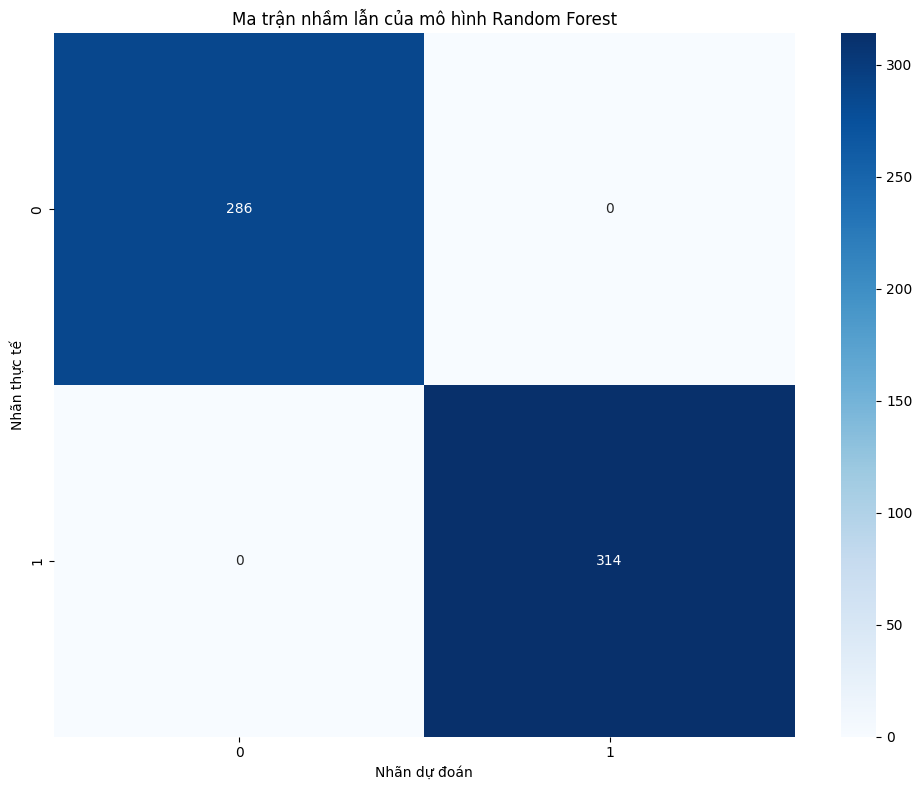

In [9]:
labels = rf_model.classes_

cm = confusion_matrix(y_test, y_test_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
# plt.savefig(
#     "../outputs/figures/confusion_matrix.png"
# )

plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.title("Ma trận nhầm lẫn của mô hình Random Forest")
plt.tight_layout()
plt.show()